# XPCS analysis

Load a scan, select peaks (click or type), fit a Gaussian, build the full Q-map, run equal-intensity masks + multitau g2 + two-time, and save one HDF5.

The Gaussian fit is required. Cropping is only a bounding box around that fit so g2 does not run on the full detector.

In [1]:
import sys
sys.path.append('../src/')

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from scan import load_scan, resolve_work_path
from preprocess import PeakPicker, parse_peaks, fit_peaks, build_qmap, refine_beam_center, tth_profile
from pipeline import analyze_peaks, mask_overlay, save_results, default_results_path
from xpcs import q_to_tth

%matplotlib widget

# User parameters

In [2]:
Beamline = '8IDE'
Geometry = 'Vertical'
Compound = 'NBH'

Particle = 'A7'
Temperature = 420
Scan = 363
Attenuation = 20

D = 2200  # mm; set None to use metadata det_dist
X0 = 1186.47  # metadata bcx unless set
Y0 = 2031.47  # metadata bcy unless set

# Fit / ROI (ROI half-widths in units of the fitted Gaussian σ)
fit_half_window = 80  # pixels around each click/typed seed
Xv = 5
Xh = 3.5

# Equal-intensity mask (const_int_mask)
maskSize = 1.5
numRings = 5
numSlices = 1
tol = 0.02
res = 1e-4
Tilted_Mask = True

# XPCS
dpl = 6
do_twotime = True

# Peak seeds: typed list, or leave empty and click on the next plot
# (col, row) or {"col": ..., "row": ...}
peaks = []
# peaks = [(1072, 675)]

# Known Bragg 2θ (degrees), same order as peaks. Empty skips beam-center refine.
tth_targets = []
# tth_targets = [10.5745]

config_path = Path('../configs/config_B10.json')
config = json.loads(config_path.read_text()) if config_path.exists() else {}

# Load scan

In [3]:
work_path = resolve_work_path(Compound, Scan, Temperature, Attenuation, config=config)
print('Directory:', work_path)

scan = load_scan(
    Beamline,
    work_path,
    geometry=Geometry,
    D=D,
    X0=X0,
    Y0=Y0,
    particle=Particle,
    temperature=Temperature,
    scan=Scan,
    attenuation=Attenuation,
)
det_sum = np.mean(scan.det[:5], axis=0)
print(f'det {scan.det.shape}  D={scan.D} mm  X0,Y0=({scan.X0:.2f}, {scan.Y0:.2f})  '
      f'ttheta={scan.ttheta:.4f}  λ={scan.wavelength:.5f} Å')

Directory: /Users/eriklamb/data/APS/8_ID_E/Na2B10H10/A363_NaBH_att000020_420K_001
det (3000, 1813, 1558)  D=2200.0 mm  X0,Y0=(1186.47, 2031.47)  ttheta=8.0046  λ=0.99984 Å


# Select peaks

If `peaks` is empty, click the image. Then run the fit cell. Typed `peaks` skips clicking.

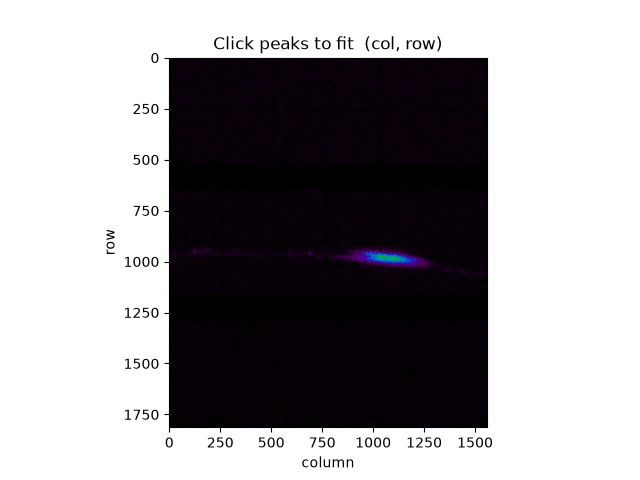

In [4]:
picker = PeakPicker(det_sum)
if peaks:
    for col, row in parse_peaks(peaks):
        picker.add(col, row)

# Fit Gaussians

peak 0: col=1074.19  row=982.01  sig_col=73.91  sig_row=12.83  tilt=-0.100


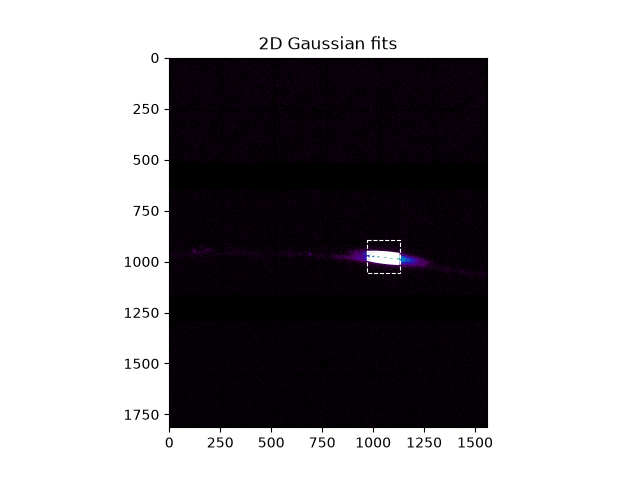

In [5]:
selected = parse_peaks(peaks) if peaks else picker.peaks
if not selected:
    raise RuntimeError('No peaks selected. Click the detector image or set peaks = [(col, row), ...]')

fits = fit_peaks(det_sum, selected, half_window=fit_half_window)
for i, fit in enumerate(fits):
    print(f'peak {i}: col={fit.col:.2f}  row={fit.row:.2f}  '
          f'sig_col={fit.sig_col:.2f}  sig_row={fit.sig_row:.2f}  tilt={fit.tilt:.3f}')

from matplotlib.patches import Rectangle

fig, ax = plt.subplots()
ax.imshow(det_sum + 1, cmap='nipy_spectral', norm=LogNorm(vmin=1, vmax=35))
for fit in fits:
    r0, r1, c0, c1 = fit.window
    yw, xw = np.mgrid[r0:r1, c0:c1]
    ax.contour(xw, yw, fit.fitted[r0:r1, c0:c1], 5, colors='w')
    ax.add_patch(Rectangle((c0, r0), c1 - c0, r1 - r0, fill=False, edgecolor='w', ls='--', lw=0.8))
    ax.plot(fit.col, fit.row, 'wx')
ax.set_title('2D Gaussian fits')
plt.show()

# Q-map

Optional: set `tth_targets` to known Bragg 2θ (one per peak) to refine X0/Y0, then rebuild.

Q-map (1813, 1558)  |Q| range 0.9241–1.3345 Å⁻¹


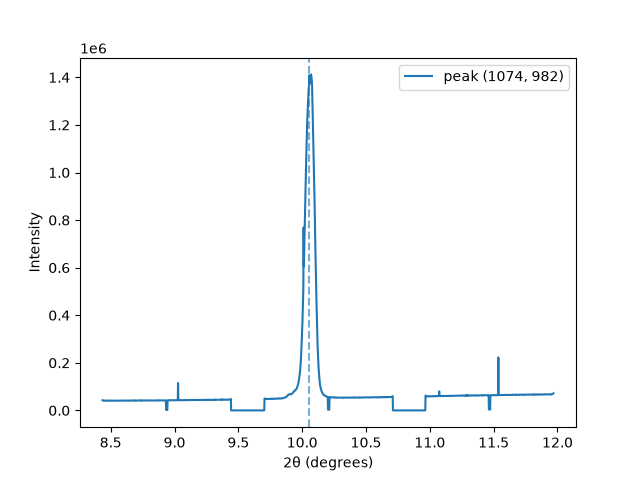

In [6]:
if tth_targets:
    shift = refine_beam_center(scan, fits, tth_targets)
    print(f"beam center {shift['X0_old']:.2f}, {shift['Y0_old']:.2f} -> "
          f"{shift['X0']:.2f}, {shift['Y0']:.2f}")

Qx, Qy = build_qmap(scan)
print(f'Q-map {Qx.shape}  |Q| range {np.min(np.hypot(Qx, Qy)):.4f}–{np.max(np.hypot(Qx, Qy)):.4f} Å⁻¹')

fig, ax = plt.subplots()
for fit in fits:
    TTH, INT = tth_profile(Qx, Qy, scan.det, scan.wavelength, scan.geometry, col=int(round(fit.col)))
    ax.plot(TTH, INT, label=f'peak ({fit.col:.0f}, {fit.row:.0f})')
    ax.axvline(q_to_tth(np.hypot(Qx[int(round(fit.row)), int(round(fit.col))],
                                 Qy[int(round(fit.row)), int(round(fit.col))]), scan.wavelength),
               ls='--', alpha=0.6)
for tth in tth_targets:
    ax.axvline(tth, color='k', alpha=0.3)
ax.set_xlabel('2θ (degrees)')
ax.set_ylabel('Intensity')
ax.legend()
plt.show()

# Masks, g2, two-time

In [7]:
results = analyze_peaks(
    scan, Qx, Qy, fits,
    xv=Xv, xh=Xh,
    mask_size=maskSize,
    num_rings=numRings,
    num_slices=numSlices,
    tilt=0.0 if not Tilted_Mask else None,
    tol=tol,
    res=res,
    dpl=dpl,
    do_twotime=do_twotime,
)
for i, r in enumerate(results):
    print(f'peak {i}: ROI {r["roi"].tolist()}  partitions {r["masks"].shape[0]}  '
          f'dQ {r["dQ"]}')

0.19619422962195718
0.19622623278420928
0.19602355584998335
0.196082584555473
0.19611622740398868
[0.5821 0.8346 1.0519 1.2606 1.4788]


two-time partitions: 100%|██████████| 5/5 [00:28<00:00,  5.65s/it]

peak 0: ROI [908, 1056, 816, 1332]  partitions 5  dQ [0.00407079 0.00751022 0.00994991 0.01215597 0.01440409]


# Check masks and g2

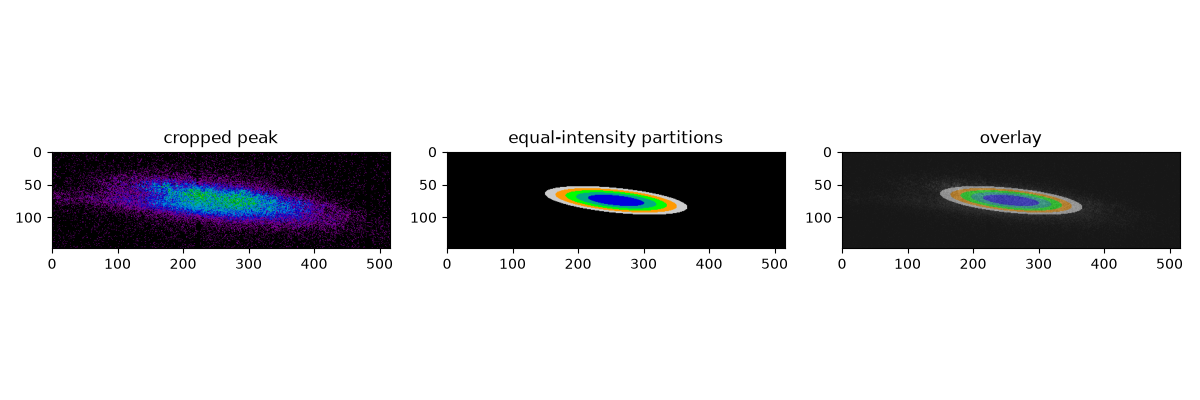

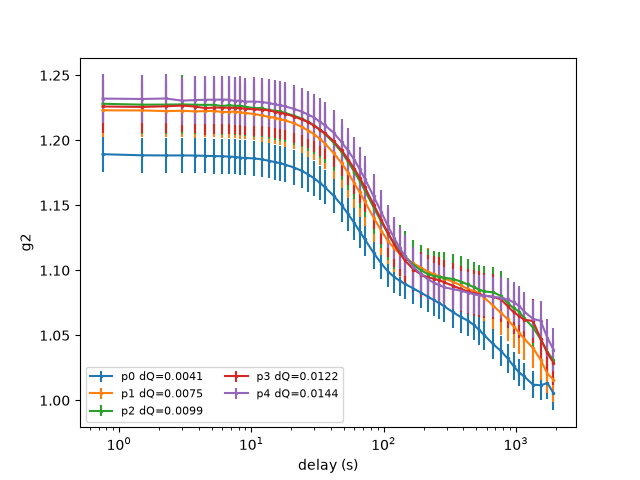

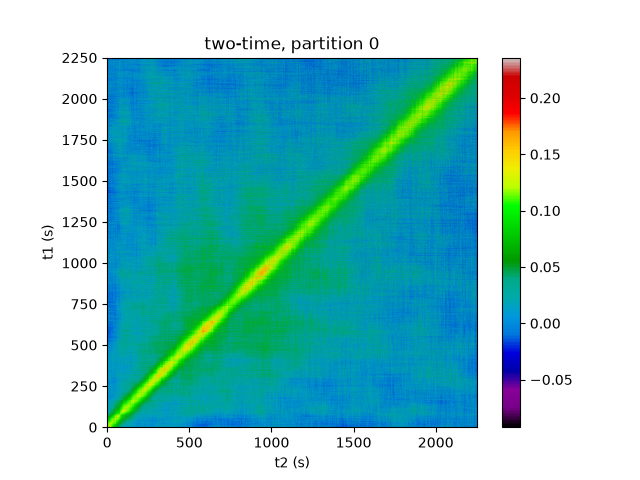

In [8]:
peak_i = 0
r = results[peak_i]
overlay = mask_overlay(r['masks'])

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(np.mean(r['det_crop'][:5], axis=0) + 1, cmap='nipy_spectral', norm=LogNorm(vmin=1, vmax=35))
axs[0].set_title('cropped peak')
axs[1].imshow(overlay, cmap='nipy_spectral')
axs[1].set_title('equal-intensity partitions')
axs[2].imshow(overlay, cmap='nipy_spectral', alpha=0.85)
axs[2].imshow(np.mean(r['det_crop'][:5], axis=0) + 1, cmap='gray', norm=LogNorm(vmin=1, vmax=35), alpha=0.4)
axs[2].set_title('overlay')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
delay = np.ravel(r['delays'])
for i in range(r['G2'].shape[0]):
    ax.errorbar(delay, r['G2'][i], yerr=r['G2_error'][i], fmt='.-', ms=3, label=f'p{i} dQ={r["dQ"][i]:.4f}')
ax.set_xscale('log')
ax.set_xlabel('delay (s)')
ax.set_ylabel('g2')
ax.legend(fontsize=8, ncol=2)
plt.show()

if r['TwoTime'] is not None:
    fig, ax = plt.subplots()
    C = r['TwoTime'][0]
    tmax = scan.frame_spacing * C.shape[0]
    im = ax.imshow(C, origin='lower', extent=[0, tmax, 0, tmax], cmap='nipy_spectral')
    ax.set_xlabel('t2 (s)')
    ax.set_ylabel('t1 (s)')
    ax.set_title('two-time, partition 0')
    fig.colorbar(im, ax=ax)
    plt.show()

# Save

In [9]:
out = default_results_path(scan, maskSize, numRings, numSlices)
save_results(
    out, scan, Qx, Qy, results,
    xv=Xv, xh=Xh,
    mask_size=maskSize,
    num_rings=numRings,
    num_slices=numSlices,
    dpl=dpl,
)
print(f'saved {out}')

saved /Users/eriklamb/data/APS/8_ID_E/Na2B10H10/A363_NaBH_att000020_420K_001/results/particleA7_temp420K_scan363_ms1.5_nr5ns1.h5
